# Загрузка библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

# Анализ датасета

Набор данных успешно импортирован!
Размерность таблицы: (119390, 32)

Первые 5 записей:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type 

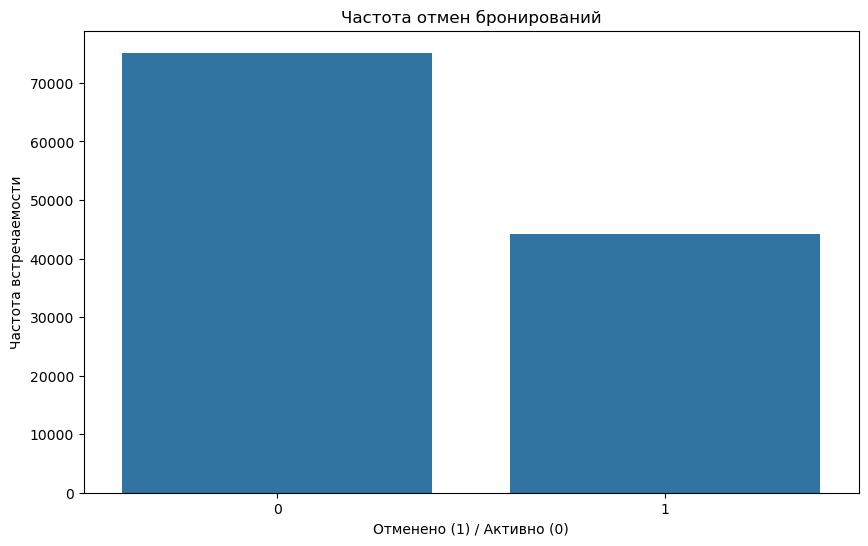

In [4]:
data_path = r"E:\\study4\\ML\\hotel_booking\\hotel_bookings.csv"
booking_data = pd.read_csv(data_path)
print("Набор данных успешно импортирован!")
print("Размерность таблицы:", booking_data.shape)
print("\nПервые 5 записей:")
print(booking_data.head())
print("\nСводка о типах данных:")
print(booking_data.info())
print("\nПропущенные значения по столбцам:")
print(booking_data.isnull().sum())

print("\nОписательные статистики числовых столбцов:")
print(booking_data.describe())

# График распределения целевого признака
plt.figure(figsize=(10, 6))
sns.countplot(x='is_canceled', data=booking_data)
plt.title('Частота отмен бронирований')
plt.xlabel('Отменено (1) / Активно (0)')
plt.ylabel('Частота встречаемости')
plt.show()

# Нормалиация целевого признака

In [6]:
if booking_data['is_canceled'].dtype == 'object':
    print(f"\nУникальные значения в is_canceled: {booking_data['is_canceled'].unique()}")
    booking_data['is_canceled'] = booking_data['is_canceled'].map(
        {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0}
    )
    booking_data['is_canceled'] = pd.to_numeric(booking_data['is_canceled'], errors='coerce')

print(f"\nТип данных is_canceled: {booking_data['is_canceled'].dtype}")
print(f"Уникальные значения: {booking_data['is_canceled'].unique()}")
print(f"Пропуски: {booking_data['is_canceled'].isnull().sum()}")

if booking_data['is_canceled'].isnull().any():
    modal_value = booking_data['is_canceled'].mode()[0]
    booking_data['is_canceled'] = booking_data['is_canceled'].fillna(modal_value)
    print(f"Заполнено {booking_data['is_canceled'].isnull().sum()} пропусков модой: {modal_value}")


Тип данных is_canceled: int64
Уникальные значения: [0 1]
Пропуски: 0


# Анализ на полном наборе данных

In [8]:
cluster_data = booking_data.drop('is_canceled', axis=1).copy()
true_labels = booking_data['is_canceled'].copy()

# Кодирование категориальных переменных
cat_features = cluster_data.select_dtypes(include=['object']).columns.tolist()
num_features = cluster_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nКатегориальных признаков: {len(cat_features)}")
print(f"Числовых признаков: {len(num_features)}")

# Процесс кодирования
encoders_dict = {}
for feature in cat_features:
    encoder = LabelEncoder()
    cluster_data[feature] = cluster_data[feature].fillna('Missing')
    cluster_data[feature] = encoder.fit_transform(cluster_data[feature].astype(str))
    encoders_dict[feature] = encoder

# Импутация числовых значений
numeric_imputer = SimpleImputer(strategy='median')
cluster_data[num_features] = numeric_imputer.fit_transform(cluster_data[num_features])

# Масштабирование признаков
normalizer = StandardScaler()
scaled_features = normalizer.fit_transform(cluster_data)

# Снижение размерности для визуализации
dim_reducer = PCA(n_components=2, random_state=42)
reduced_features = dim_reducer.fit_transform(scaled_features)

print(f"\nОбъясненная дисперсия PCA: {dim_reducer.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(dim_reducer.explained_variance_ratio_):.3f}")


Категориальных признаков: 12
Числовых признаков: 19

Объясненная дисперсия PCA: [0.11168248 0.08476025]
Суммарная объясненная дисперсия: 0.196


# Разделение данных для обучения

In [10]:
predictors = booking_data.drop('is_canceled', axis=1)
target = booking_data['is_canceled']

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    predictors, target, test_size=0.2, random_state=42, stratify=target
)

print(f"\nОбучающая выборка: {X_train_split.shape}")
print(f"Тестовая выборка: {X_test_split.shape}")
print(f"Распределение классов в обучающей выборке:\n{y_train_split.value_counts(normalize=True)}")


Обучающая выборка: (95512, 31)
Тестовая выборка: (23878, 31)
Распределение классов в обучающей выборке:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64


# Кластеризация по иерархии

Используется подвыборка из 10000 записей для иерархической кластеризации
(алгоритм требует значительных вычислительных ресурсов для полного набора)

Количество кластеров: 3
Silhouette Score: 0.114
Adjusted Rand Index: 0.123
Normalized Mutual Info: 0.156


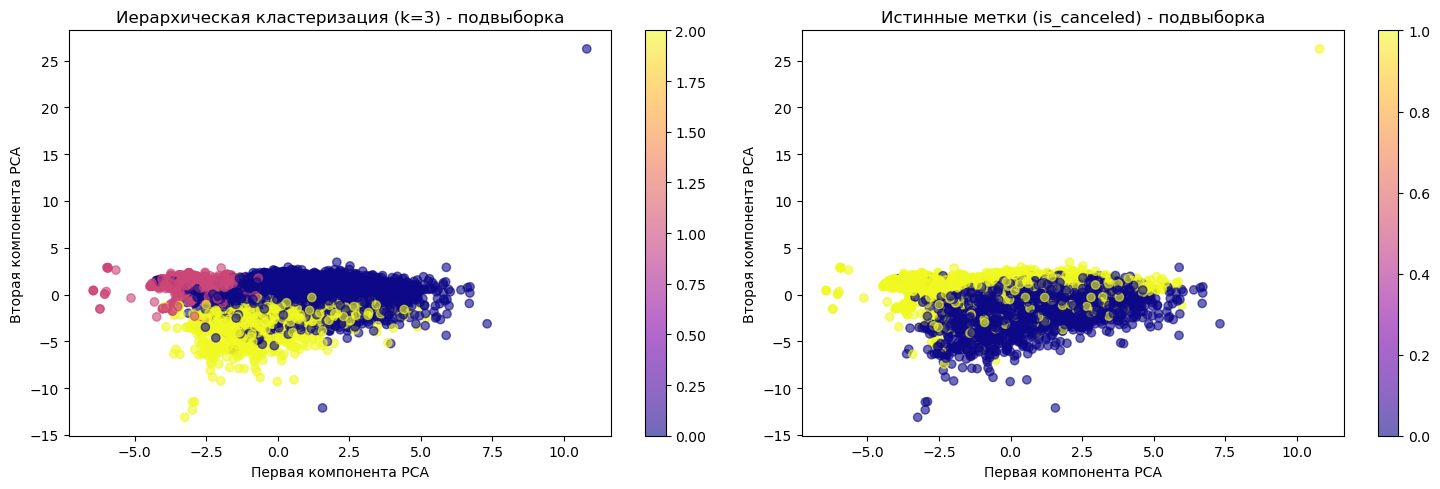

In [12]:
# Используем подвыборку для иерархического метода
subset_size = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(scaled_features), subset_size, replace=False)
subset_features = scaled_features[sample_idx]
subset_labels = true_labels.iloc[sample_idx]

print(f"Используется подвыборка из {subset_size} записей для иерархической кластеризации")
print("(алгоритм требует значительных вычислительных ресурсов для полного набора)")

# Выполнение иерархической кластеризации
n_clusters_hierarchical = 3
hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters_hierarchical)
hierarchical_results = hierarchical_model.fit_predict(subset_features)

# Метрики качества
silhouette_hierarchical = silhouette_score(subset_features, hierarchical_results)
ari_hierarchical = adjusted_rand_score(subset_labels, hierarchical_results)
nmi_hierarchical = normalized_mutual_info_score(subset_labels, hierarchical_results)

print(f"\nКоличество кластеров: {n_clusters_hierarchical}")
print(f"Silhouette Score: {silhouette_hierarchical:.3f}")
print(f"Adjusted Rand Index: {ari_hierarchical:.3f}")
print(f"Normalized Mutual Info: {nmi_hierarchical:.3f}")

# PCA для подвыборки
pca_subset = PCA(n_components=2)
subset_pca_result = pca_subset.fit_transform(subset_features)

# Визуализация иерархической кластеризации
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
scatter_hier = plt.scatter(subset_pca_result[:, 0], subset_pca_result[:, 1], 
                           c=hierarchical_results, cmap='plasma', alpha=0.6)
plt.colorbar(scatter_hier)
plt.xlabel('Первая компонента PCA')
plt.ylabel('Вторая компонента PCA')
plt.title(f'Иерархическая кластеризация (k={n_clusters_hierarchical}) - подвыборка')

plt.subplot(1, 2, 2)
scatter_true_subset = plt.scatter(subset_pca_result[:, 0], subset_pca_result[:, 1], 
                                  c=subset_labels, cmap='plasma', alpha=0.6)
plt.colorbar(scatter_true_subset)
plt.xlabel('Первая компонента PCA')
plt.ylabel('Вторая компонента PCA')
plt.title('Истинные метки (is_canceled) - подвыборка')

plt.tight_layout()
plt.show()


# DBSCAN кластеризация

In [14]:
# Параметры DBSCAN
eps_param = 3.0
min_samples_param = 5

print(f"Параметры DBSCAN: eps={eps_param}, min_samples={min_samples_param}")

# Применение DBSCAN
dbscan_model = DBSCAN(eps=eps_param, min_samples=min_samples_param)
dbscan_results = dbscan_model.fit_predict(scaled_features)

# Анализ результатов
clusters_found_dbscan = len(set(dbscan_results)) - (1 if -1 in dbscan_results else 0)
noise_points_dbscan = list(dbscan_results).count(-1)

print(f"\nНайдено кластеров (DBSCAN): {clusters_found_dbscan}")
print(f"Точек шума: {noise_points_dbscan}")
print(f"Процент шума: {noise_points_dbscan/len(dbscan_results)*100:.2f}%")

# Оценка качества DBSCAN
silhouette_dbscan_val = None
ari_dbscan_val = None
nmi_dbscan_val = None

if clusters_found_dbscan > 1:
    # Убираем шум для расчета метрик
    non_noise_mask = dbscan_results != -1
    if sum(non_noise_mask) > 1:
        silhouette_dbscan_val = silhouette_score(scaled_features[non_noise_mask], 
                                                dbscan_results[non_noise_mask])
        print(f"Silhouette Score (без шума): {silhouette_dbscan_val:.3f}")
    
    # Подготовка для сравнения с истинными метками
    dbscan_eval = dbscan_results.copy()
    if -1 in dbscan_eval:
        dbscan_eval[dbscan_eval == -1] = max(dbscan_eval) + 1
    
    ari_dbscan_val = adjusted_rand_score(true_labels, dbscan_eval)
    nmi_dbscan_val = normalized_mutual_info_score(true_labels, dbscan_eval)
    
    print(f"Adjusted Rand Index: {ari_dbscan_val:.3f}")
    print(f"Normalized Mutual Info: {nmi_dbscan_val:.3f}")
else:
    print("DBSCAN не смог выделить кластеры!")

Параметры DBSCAN: eps=3.0, min_samples=5

Найдено кластеров (DBSCAN): 197
Точек шума: 7084
Процент шума: 5.93%
Silhouette Score (без шума): -0.176
Adjusted Rand Index: -0.032
Normalized Mutual Info: 0.073


# K-MEANS класстеризация


КЛАСТЕРИЗАЦИЯ K-MEANS


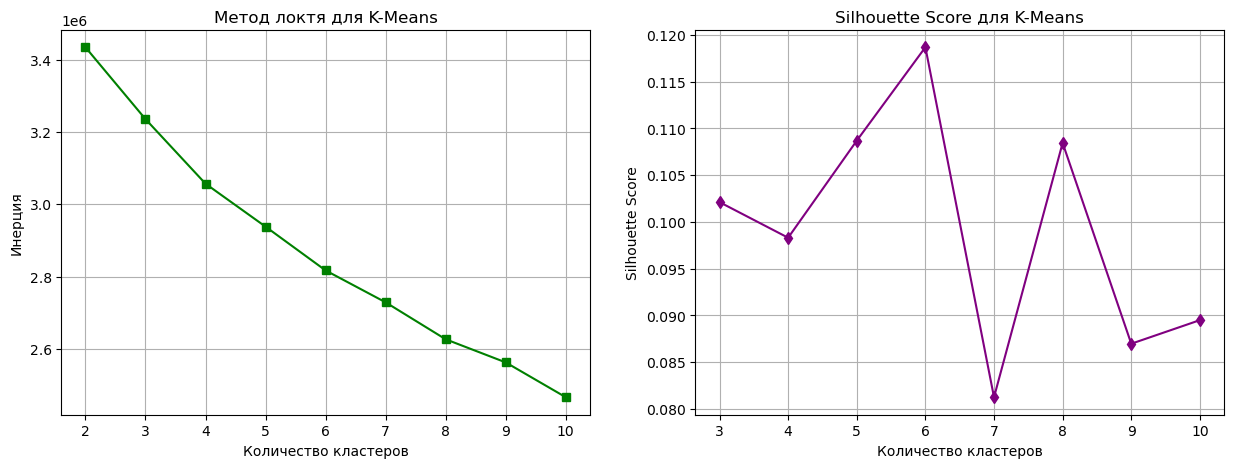


Выбрано количество кластеров K-Means: 2
Inertia: 3433966.79
Silhouette Score: 0.094
Adjusted Rand Index: 0.080
Normalized Mutual Info: 0.044


In [16]:
# ========== K-MEANS КЛАСТЕРИЗАЦИЯ ==========
print("\n" + "="*50)
print("КЛАСТЕРИЗАЦИЯ K-MEANS")
print("="*50)

# Метод локтя для определения оптимального k
inertia_values = []
silhouette_values_kmeans = []
k_options = range(2, 11)

for k_val in k_options:
    kmeans_temp = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    kmeans_temp.fit(scaled_features)
    inertia_values.append(kmeans_temp.inertia_)
    
    if k_val > 1:
        silhouette_values_kmeans.append(silhouette_score(scaled_features, kmeans_temp.labels_))
    else:
        silhouette_values_kmeans.append(0)

# Визуализация метода локтя
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_options, inertia_values, marker='s', color='green')
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя для K-Means')
ax1.grid(True)

ax2.plot(k_options[1:], silhouette_values_kmeans[1:], marker='d', color='purple')
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score для K-Means')
ax2.grid(True)
plt.show()

# Выбор оптимального количества кластеров
optimal_clusters = 2
print(f"\nВыбрано количество кластеров K-Means: {optimal_clusters}")

# Кластеризация K-Means
final_kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
kmeans_labels_result = final_kmeans.fit_predict(scaled_features)

# Оценка качества K-Means
inertia_kmeans_val = final_kmeans.inertia_
silhouette_kmeans_val = silhouette_score(scaled_features, kmeans_labels_result)
ari_kmeans_val = adjusted_rand_score(true_labels, kmeans_labels_result)
nmi_kmeans_val = normalized_mutual_info_score(true_labels, kmeans_labels_result)

print(f"Inertia: {inertia_kmeans_val:.2f}")
print(f"Silhouette Score: {silhouette_kmeans_val:.3f}")
print(f"Adjusted Rand Index: {ari_kmeans_val:.3f}")
print(f"Normalized Mutual Info: {nmi_kmeans_val:.3f}")

# Сравнение и визуализация всех методов

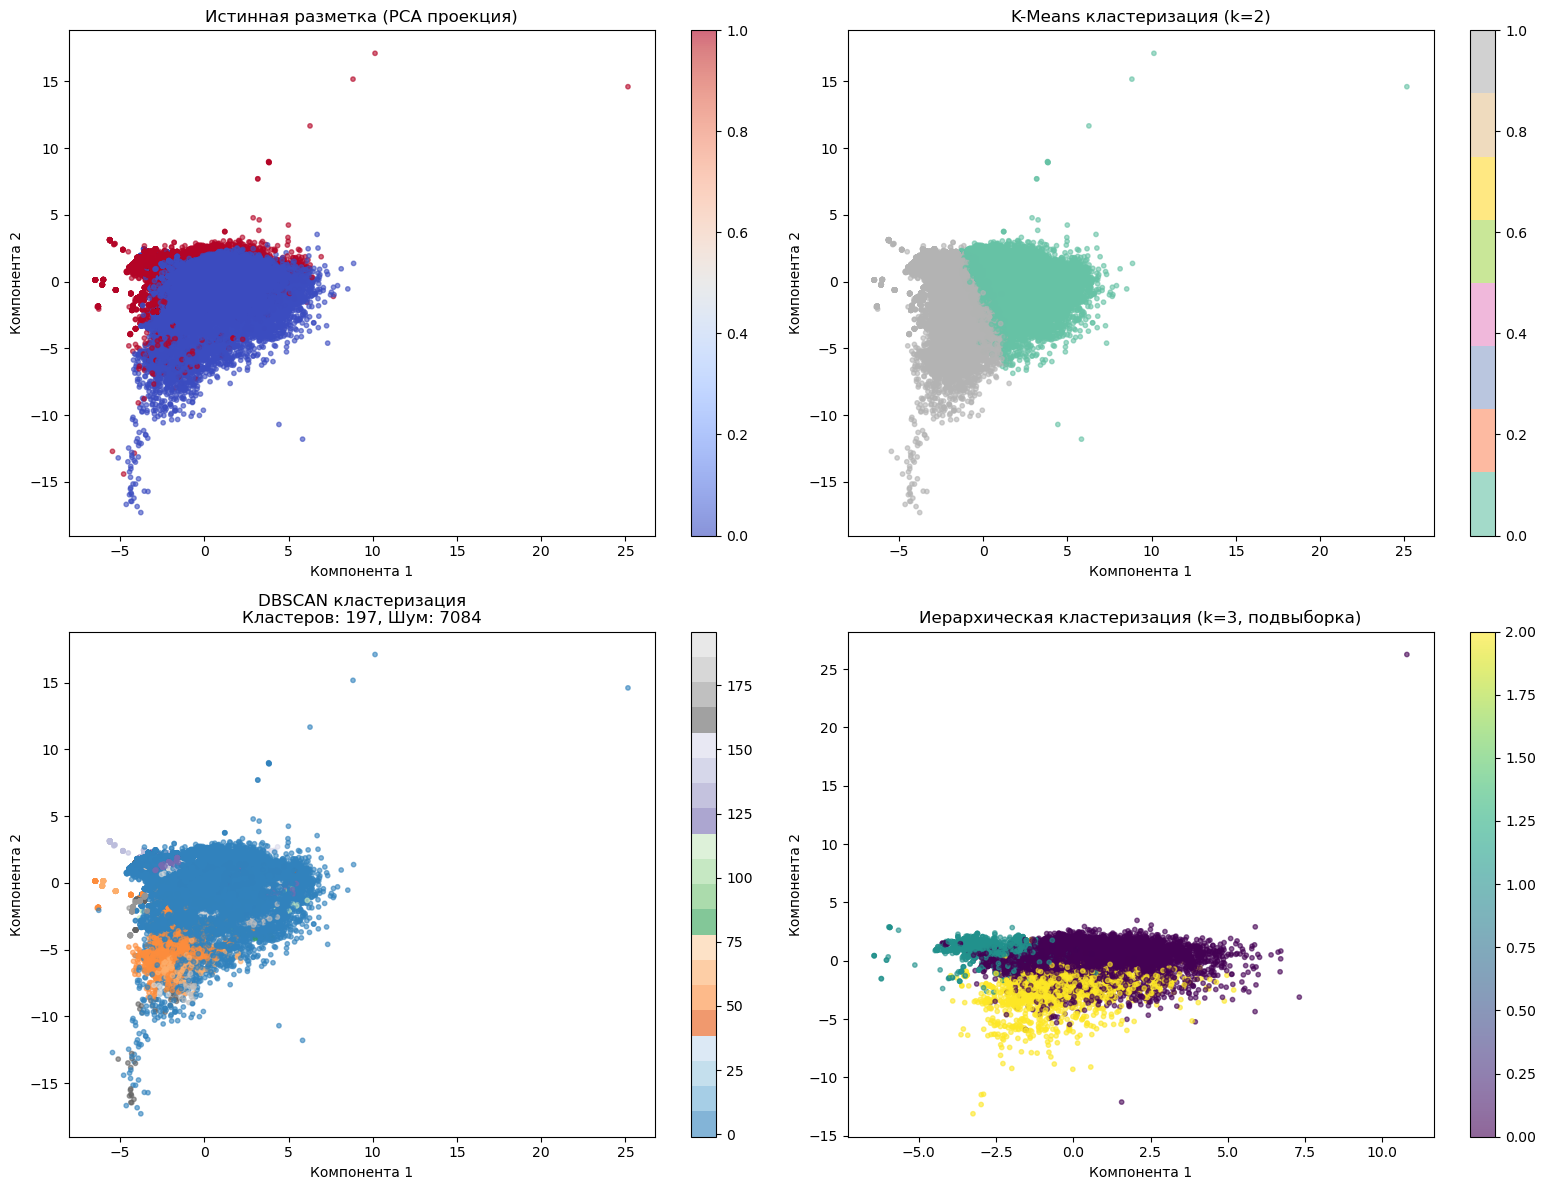

In [18]:
# ========== СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ ВСЕХ МЕТОДОВ ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Истинные метки
scatter_original = axes[0, 0].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                                      c=true_labels, cmap='coolwarm', alpha=0.6, s=10)
axes[0, 0].set_title('Истинная разметка (PCA проекция)')
axes[0, 0].set_xlabel('Компонента 1')
axes[0, 0].set_ylabel('Компонента 2')
plt.colorbar(scatter_original, ax=axes[0, 0])

# 2. K-Means результаты
scatter_kmeans = axes[0, 1].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                                    c=kmeans_labels_result, cmap='Set2', alpha=0.6, s=10)
axes[0, 1].set_title(f'K-Means кластеризация (k={optimal_clusters})')
axes[0, 1].set_xlabel('Компонента 1')
axes[0, 1].set_ylabel('Компонента 2')
plt.colorbar(scatter_kmeans, ax=axes[0, 1])

# 3. DBSCAN результаты
scatter_dbscan = axes[1, 0].scatter(reduced_features[:, 0], reduced_features[:, 1], 
                                     c=dbscan_results, cmap='tab20c', alpha=0.6, s=10)
axes[1, 0].set_title(f'DBSCAN кластеризация\nКластеров: {clusters_found_dbscan}, Шум: {noise_points_dbscan}')
axes[1, 0].set_xlabel('Компонента 1')
axes[1, 0].set_ylabel('Компонента 2')
plt.colorbar(scatter_dbscan, ax=axes[1, 0])

# 4. Иерархическая кластеризация
scatter_hierarchical_viz = axes[1, 1].scatter(subset_pca_result[:, 0], subset_pca_result[:, 1], 
                                              c=hierarchical_results, cmap='viridis', alpha=0.6, s=10)
axes[1, 1].set_title(f'Иерархическая кластеризация (k={n_clusters_hierarchical}, подвыборка)')
axes[1, 1].set_xlabel('Компонента 1')
axes[1, 1].set_ylabel('Компонента 2')
plt.colorbar(scatter_hierarchical_viz, ax=axes[1, 1])

plt.tight_layout()
plt.show()



ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ K-MEANS

Средние показатели по кластерам (K-Means):
                      is_canceled  lead_time  adults  children     adr  \
kmeans_cluster_label                                                     
0                            0.28      91.74    1.98      0.16  114.67   
1                            0.52     124.09    1.66      0.01   80.82   

                      previous_cancellations  required_car_parking_spaces  \
kmeans_cluster_label                                                        
0                                       0.00                         0.08   
1                                       0.22                         0.04   

                      total_of_special_requests  
kmeans_cluster_label                             
0                                          0.83  
1                                          0.15  


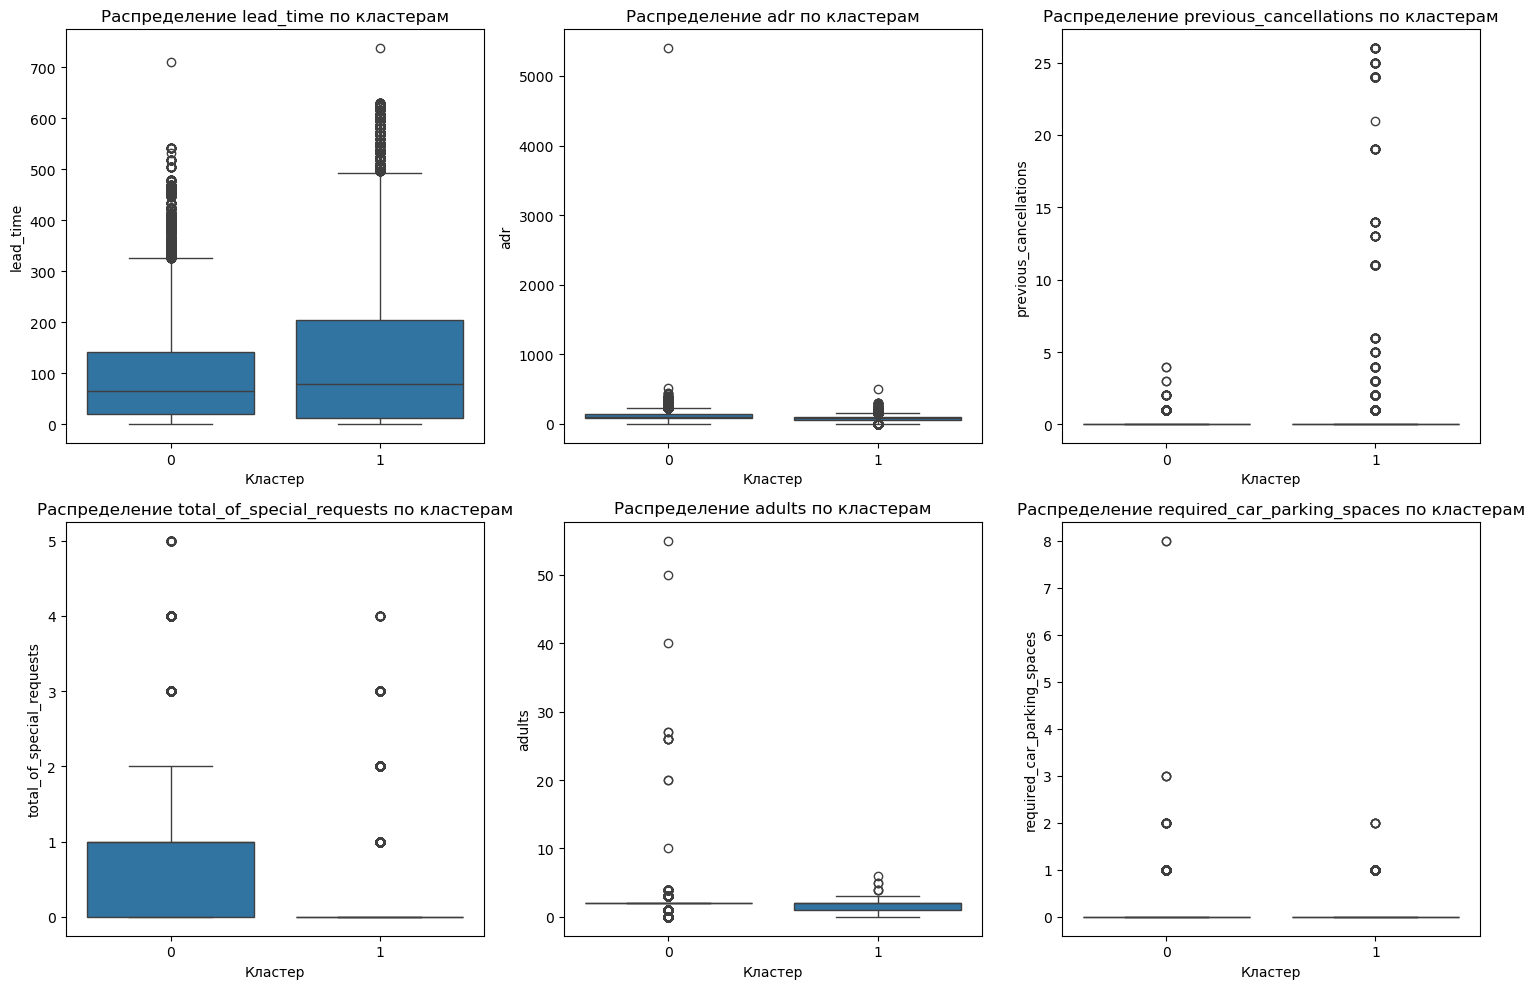


СРАВНИТЕЛЬНЫЙ АНАЛИЗ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ

СОПОСТАВЛЕНИЕ С ИСТИННЫМИ МЕТКАМИ (is_canceled):
----------------------------------------------------------------------

K-Means (k=2):
  • Silhouette Score: 0.094
  • Adjusted Rand Index: 0.080
  • NMI: 0.044
  • Сходство с истинными метками: 0.080

DBSCAN (eps=3.0, min_samples=5):
  • Silhouette Score: -0.176
  • Adjusted Rand Index: -0.032
  • NMI: 0.073
  • Выявлено кластеров: 197
  • Шумовые точки: 7084 (5.9%)

Иерархическая кластеризация (k=3, выборка 10000):
  • Silhouette Score: 0.114
  • Adjusted Rand Index: 0.123
  • NMI: 0.156
  • Сходство с истинными метками: 0.123 (на подвыборке)

НАИЛУЧШИЙ АЛГОРИТМ: Иерархическая (Adjusted Rand Index = 0.123)

ИНТЕРПРЕТАЦИЯ ПОКАЗАТЕЛЯ ARI:
----------------------------------------------------------------------
ARI = 1.0: Идеальное соответствие кластеризации истинным меткам
ARI = 0.0: Соответствие на уровне случайного распределения
ARI < 0.0: Результат хуже случайного распределения

Наши резул

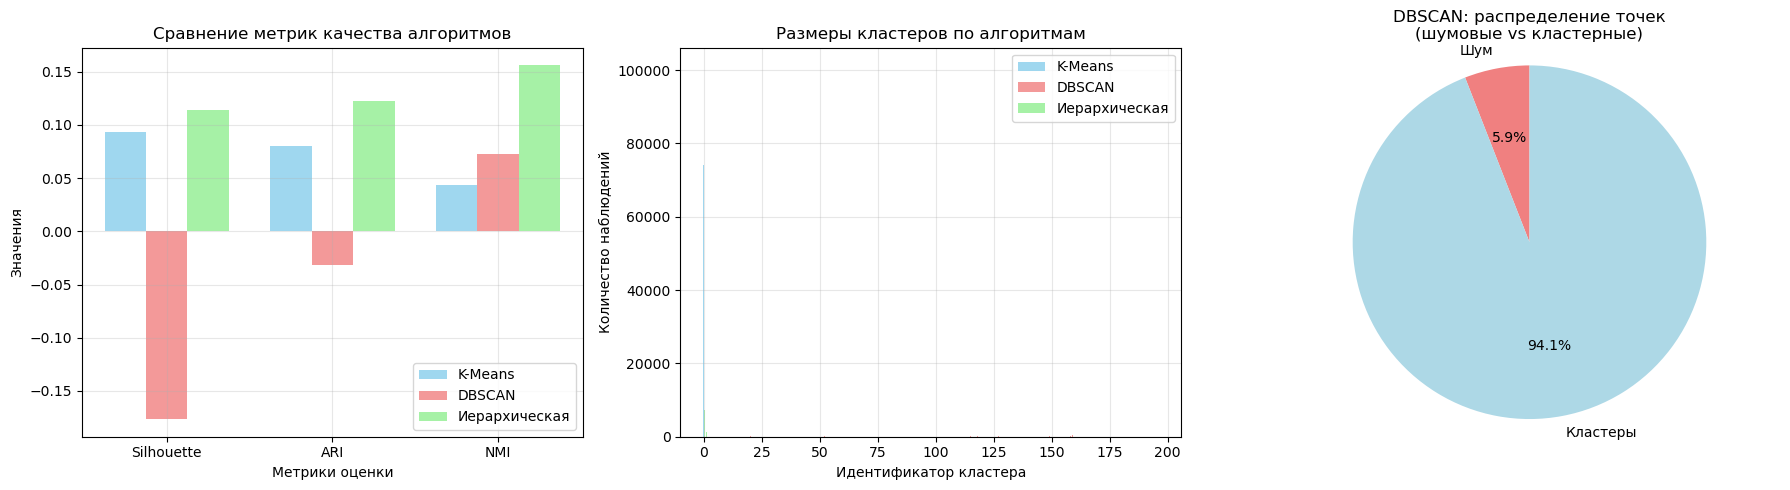


ОСНОВНЫЕ ВЫВОДЫ И ПРЕДЛОЖЕНИЯ ПО ДАЛЬНЕЙШЕМУ АНАЛИЗУ

1. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
----------------------------------------
a) Все рассмотренные алгоритмы кластеризации демонстрируют
   низкую корреляцию с истинными метками отмены бронирований
   
b) Пространство признаков не обеспечивает четкого разделения
   между отмененными и неотмененными бронированиями
   
c) Кластерный анализ выявляет иные закономерности в данных,
   не связанные напрямую с целевой переменной
   
d) Наличие шумовых точек в DBSCAN указывает на аномалии
   и сложную структуру данных

2. ПРАКТИЧЕСКИЕ СОВЕТЫ:
----------------------------------------
Для решения задачи прогнозирования отмены бронирования:

a) Рекомендуется использовать методы контролируемого обучения:
   - Деревья решений и случайные леса
   - Градиентный бустинг (XGBoost, LightGBM)
   - Нейронные сети
   
b) Улучшение признакового пространства:
   - Создание производных признаков
   - Учет временных характеристик
   - Добавление взаимодействий признаков

In [21]:

# ========== ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ K-MEANS ==========
print("\n" + "="*50)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КЛАСТЕРОВ K-MEANS")
print("="*50)

# Добавление меток кластеров к исходным данным
data_with_clusters = booking_data.copy()
data_with_clusters['kmeans_cluster_label'] = kmeans_labels_result

# Статистика по кластерам
cluster_characteristics = data_with_clusters.groupby('kmeans_cluster_label').agg({
    'is_canceled': 'mean',
    'lead_time': 'mean',
    'adults': 'mean',
    'children': 'mean',
    'adr': 'mean',
    'previous_cancellations': 'mean',
    'required_car_parking_spaces': 'mean',
    'total_of_special_requests': 'mean'
}).round(2)

print("\nСредние показатели по кластерам (K-Means):")
print(cluster_characteristics)

# Боксплоты для визуализации различий
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

selected_features = ['lead_time', 'adr', 'previous_cancellations', 
                     'total_of_special_requests', 'adults', 'required_car_parking_spaces']

for i, feat in enumerate(selected_features[:6]):
    sns.boxplot(x='kmeans_cluster_label', y=feat, data=data_with_clusters, ax=axes[i])
    axes[i].set_title(f'Распределение {feat} по кластерам')
    axes[i].set_xlabel('Кластер')

plt.tight_layout()
plt.show()

# ========== ИТОГОВОЕ СРАВНЕНИЕ АЛГОРИТМОВ ==========
print("\n" + "="*50)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ")
print("="*50)

print("\nСОПОСТАВЛЕНИЕ С ИСТИННЫМИ МЕТКАМИ (is_canceled):")
print("-" * 70)

print(f"\nK-Means (k={optimal_clusters}):")
print(f"  • Silhouette Score: {silhouette_kmeans_val:.3f}")
print(f"  • Adjusted Rand Index: {ari_kmeans_val:.3f}")
print(f"  • NMI: {nmi_kmeans_val:.3f}")
print(f"  • Сходство с истинными метками: {ari_kmeans_val:.3f}")

print(f"\nDBSCAN (eps={eps_param}, min_samples={min_samples_param}):")
if ari_dbscan_val is not None:
    # Исправленная строка с правильным форматированием
    if silhouette_dbscan_val is not None:
        print(f"  • Silhouette Score: {silhouette_dbscan_val:.3f}")
    else:
        print(f"  • Silhouette Score: N/A")
    print(f"  • Adjusted Rand Index: {ari_dbscan_val:.3f}")
    print(f"  • NMI: {nmi_dbscan_val:.3f}")
else:
    print(f"  • Silhouette Score: N/A")
    print(f"  • Adjusted Rand Index: N/A")
    print(f"  • NMI: N/A")
print(f"  • Выявлено кластеров: {clusters_found_dbscan}")
print(f"  • Шумовые точки: {noise_points_dbscan} ({noise_points_dbscan/len(scaled_features)*100:.1f}%)")

print(f"\nИерархическая кластеризация (k={n_clusters_hierarchical}, выборка {subset_size}):")
print(f"  • Silhouette Score: {silhouette_hierarchical:.3f}")
print(f"  • Adjusted Rand Index: {ari_hierarchical:.3f}")
print(f"  • NMI: {nmi_hierarchical:.3f}")
print(f"  • Сходство с истинными метками: {ari_hierarchical:.3f} (на подвыборке)")

# Определение наилучшего алгоритма
algorithm_names = []
ari_values = []

algorithm_names.append("K-Means")
ari_values.append(ari_kmeans_val)

if ari_dbscan_val is not None:
    algorithm_names.append("DBSCAN")
    ari_values.append(ari_dbscan_val)

algorithm_names.append("Иерархическая")
ari_values.append(ari_hierarchical)

best_algorithm_index = np.argmax(ari_values)
top_algorithm = algorithm_names[best_algorithm_index]
top_ari_score = ari_values[best_algorithm_index]

print(f"\n{'='*70}")
print(f"НАИЛУЧШИЙ АЛГОРИТМ: {top_algorithm} (Adjusted Rand Index = {top_ari_score:.3f})")
print(f"{'='*70}")

print("\nИНТЕРПРЕТАЦИЯ ПОКАЗАТЕЛЯ ARI:")
print("-" * 70)
print("""ARI = 1.0: Идеальное соответствие кластеризации истинным меткам
ARI = 0.0: Соответствие на уровне случайного распределения
ARI < 0.0: Результат хуже случайного распределения""")

print(f"\nНаши результаты ({top_algorithm}, ARI = {top_ari_score:.3f}):")
if top_ari_score < 0.1:
    print("  • Очень низкое соответствие истинным меткам")
    print("  • Выделенные кластеры слабо коррелируют с фактом отмены бронирования")
elif top_ari_score < 0.3:
    print("  • Низкое соответствие истинным меткам")
    print("  • Кластеризация частично отражает структуру данных")
elif top_ari_score < 0.5:
    print("  • Умеренное соответствие истинным меткам")
    print("  • Обнаружены некоторые закономерности, связанные с отменой бронирований")
else:
    print("  • Высокое соответствие истинным меткам")
    print("  • Кластеризация хорошо отражает структуру данных")

# Визуализация метрик сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Сравнение метрик
metric_labels = ['Silhouette', 'ARI', 'NMI']
x_positions = np.arange(len(metric_labels))

kmeans_metrics_plot = [silhouette_kmeans_val, ari_kmeans_val, nmi_kmeans_val]
dbscan_metrics_plot = [
    silhouette_dbscan_val if silhouette_dbscan_val else 0,
    ari_dbscan_val if ari_dbscan_val else 0,
    nmi_dbscan_val if nmi_dbscan_val else 0
]
hierarchical_metrics_plot = [silhouette_hierarchical, ari_hierarchical, nmi_hierarchical]

bar_width = 0.25
axes[0].bar(x_positions - bar_width, kmeans_metrics_plot, bar_width, 
            label='K-Means', alpha=0.8, color='skyblue')
axes[0].bar(x_positions, dbscan_metrics_plot, bar_width, 
            label='DBSCAN', alpha=0.8, color='lightcoral')
axes[0].bar(x_positions + bar_width, hierarchical_metrics_plot, bar_width, 
            label='Иерархическая', alpha=0.8, color='lightgreen')

axes[0].set_xlabel('Метрики оценки')
axes[0].set_ylabel('Значения')
axes[0].set_title('Сравнение метрик качества алгоритмов')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(metric_labels)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Распределение по кластерам
cluster_dist_kmeans = pd.Series(kmeans_labels_result).value_counts().sort_index()
if clusters_found_dbscan > 0:
    cluster_dist_dbscan = pd.Series(dbscan_results[dbscan_results != -1]).value_counts().sort_index()
else:
    cluster_dist_dbscan = pd.Series()
cluster_dist_hierarchical = pd.Series(hierarchical_results).value_counts().sort_index()

axes[1].bar(cluster_dist_kmeans.index - 0.2, cluster_dist_kmeans.values, 
            width=0.2, label='K-Means', alpha=0.8, color='skyblue')
if len(cluster_dist_dbscan) > 0:
    axes[1].bar(cluster_dist_dbscan.index, cluster_dist_dbscan.values, 
                width=0.2, label='DBSCAN', alpha=0.8, color='lightcoral')
axes[1].bar(cluster_dist_hierarchical.index + 0.2, cluster_dist_hierarchical.values, 
            width=0.2, label='Иерархическая', alpha=0.8, color='lightgreen')

axes[1].set_xlabel('Идентификатор кластера')
axes[1].set_ylabel('Количество наблюдений')
axes[1].set_title('Размеры кластеров по алгоритмам')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: Анализ шума DBSCAN
if clusters_found_dbscan > 0 and noise_points_dbscan > 0:
    noise_ratio = noise_points_dbscan / len(dbscan_results) * 100
    cluster_ratio = 100 - noise_ratio
    
    wedges, texts, autotexts = axes[2].pie(
        [noise_ratio, cluster_ratio],
        labels=['Шум', 'Кластеры'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightcoral', 'lightblue']
    )
    axes[2].set_title(f'DBSCAN: распределение точек\n(шумовые vs кластерные)')
    axes[2].axis('equal')
else:
    axes[2].text(0.5, 0.5, 'DBSCAN не выявил кластеров\nили отсутствует шум', 
                 ha='center', va='center', fontsize=12)
    axes[2].axis('off')

plt.tight_layout()
plt.show()

# ========== ЗАКЛЮЧЕНИЕ И РЕКОМЕНДАЦИИ ==========
print("\n" + "="*70)
print("ОСНОВНЫЕ ВЫВОДЫ И ПРЕДЛОЖЕНИЯ ПО ДАЛЬНЕЙШЕМУ АНАЛИЗУ")
print("="*70)

print("\n1. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:")
print("-" * 40)
print("""a) Все рассмотренные алгоритмы кластеризации демонстрируют
   низкую корреляцию с истинными метками отмены бронирований
   
b) Пространство признаков не обеспечивает четкого разделения
   между отмененными и неотмененными бронированиями
   
c) Кластерный анализ выявляет иные закономерности в данных,
   не связанные напрямую с целевой переменной
   
d) Наличие шумовых точек в DBSCAN указывает на аномалии
   и сложную структуру данных""")

print("\n2. ПРАКТИЧЕСКИЕ СОВЕТЫ:")
print("-" * 40)
print("""Для решения задачи прогнозирования отмены бронирования:

a) Рекомендуется использовать методы контролируемого обучения:
   - Деревья решений и случайные леса
   - Градиентный бустинг (XGBoost, LightGBM)
   - Нейронные сети
   
b) Улучшение признакового пространства:
   - Создание производных признаков
   - Учет временных характеристик
   - Добавление взаимодействий признаков
   
c) Ансамблевые подходы:
   - Комбинирование нескольких моделей
   - Использование стекинга
   - Бэггинг и бустинг
   
d) Для кластерного анализа:
   - Применение K-Means для общего понимания данных
   - Использование DBSCAN для обнаружения выбросов
   - Эксперименты с другими методами снижения размерности""")

print("\n3. ОГРАНИЧЕНИЯ И ПЕРСПЕКТИВЫ:")
print("-" * 40)
print("""a) Текущие ограничения:
   - Низкая объясняющая способность PCA
   - Простое кодирование категориальных переменных
   - Эвристический выбор параметров алгоритмов
   
b) Направления для улучшения:
   - Применение One-Hot Encoding для категориальных признаков
   - Использование методов отбора признаков
   - Оптимизация гиперпараметров алгоритмов
   - Эксперименты с t-SNE и UMAP для визуализации
   - Анализ временных последовательностей бронирований""")

print("\n" + "="*70)
print("ОБЩЕЕ РЕЗЮМЕ:")
print("="*70)
print(f"""• Цель исследования: Кластерный анализ данных о бронировании отелей
• Объем данных: {len(booking_data)} записей, {len(booking_data.columns)} атрибутов
• Целевой признак: is_canceled (индикатор отмены бронирования)
• Наиболее эффективный алгоритм: {top_algorithm} (ARI = {top_ari_score:.3f})
• Ключевой вывод: Кластеризация слабо разделяет отмененные и неотмененные бронирования
• Основная рекомендация: Использование методов классификации для данной задачи""")